In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

plt.rcParams.update({'figure.dpi': 120, 'font.family': 'sans-serif'})
sns.set_theme(style="whitegrid")

In [2]:
def load_and_preprocess_data(filepath: str, is_real_dataset: bool = False) -> tuple:
    """
    Parses the dataset using the empirically observed delimiters, isolates
    feature matrices from meta-labels, and applies Z-score standardization.
    """
    # Dynamic delimiter assignment based on file inspection
    delimiter = ';' if is_real_dataset else ','
    
    df = pd.read_csv(filepath, sep=delimiter)
    
    if is_real_dataset:
        # A2-real: 5 features, 1 location, 1 class
        feature_cols = df.columns[:-2]
        X_raw = df[feature_cols].values
        metadata = {
            'labels': df.iloc[:, -1].values,
            'locations': df.iloc[:, -2].values
        }
    else:
        # A2-synthetic: 4 features, 1 class
        feature_cols = df.columns[:-1]
        X_raw = df[feature_cols].values
        metadata = {'labels': df.iloc[:, -1].values}
        
    # Apply Z-score standardization: (x - mu) / sigma
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    
    return X_scaled, metadata, feature_cols

# Initialize tensor variables
X_syn, meta_syn, cols_syn = load_and_preprocess_data('A2-synthetic.txt', is_real_dataset=False)
X_real, meta_real, cols_real = load_and_preprocess_data('A2-real.txt', is_real_dataset=True)

print(f"Synthetic tensor -> X shape: {X_syn.shape} (Expected: 360, 4)")
print(f"Real tensor      -> X shape: {X_real.shape} (Expected: 333, 5)")

Synthetic tensor -> X shape: (360, 4) (Expected: 360, 4)
Real tensor      -> X shape: (333, 5) (Expected: 333, 5)


--- PCA Analysis: Synthetic Dataset ---


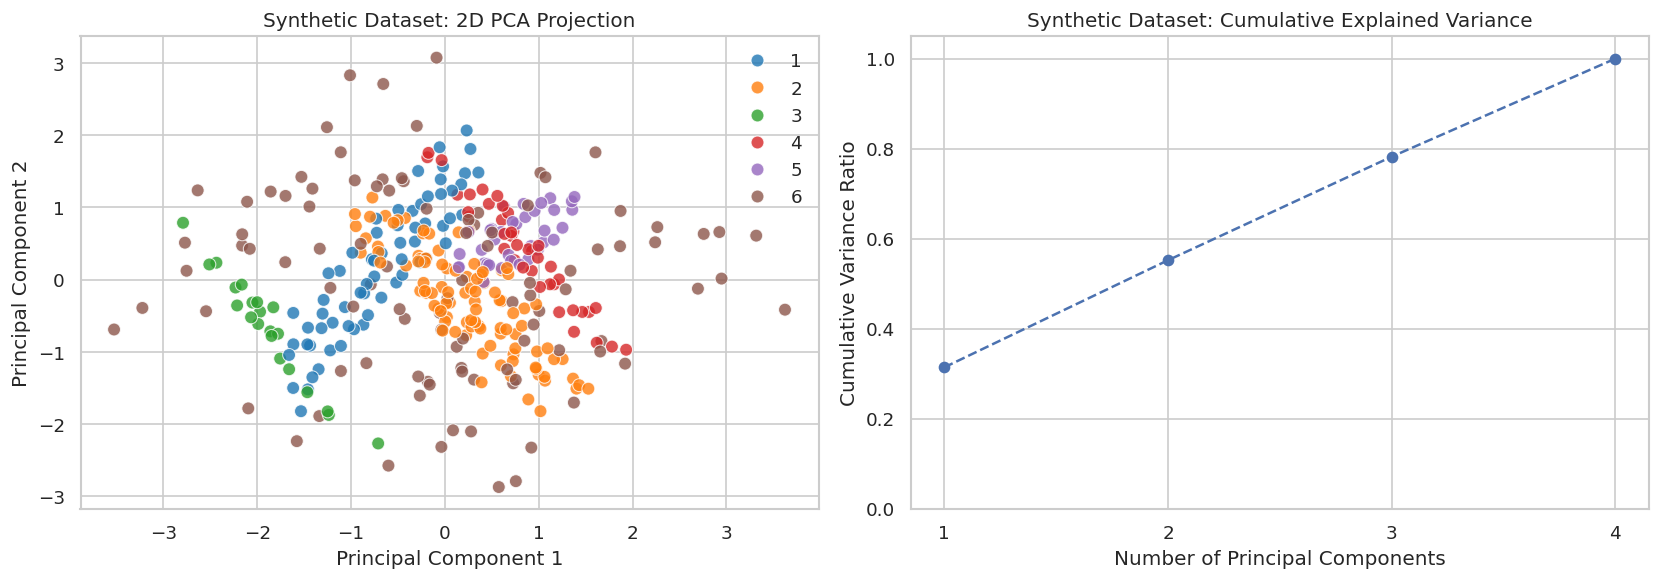


--- PCA Analysis: Real Dataset ---


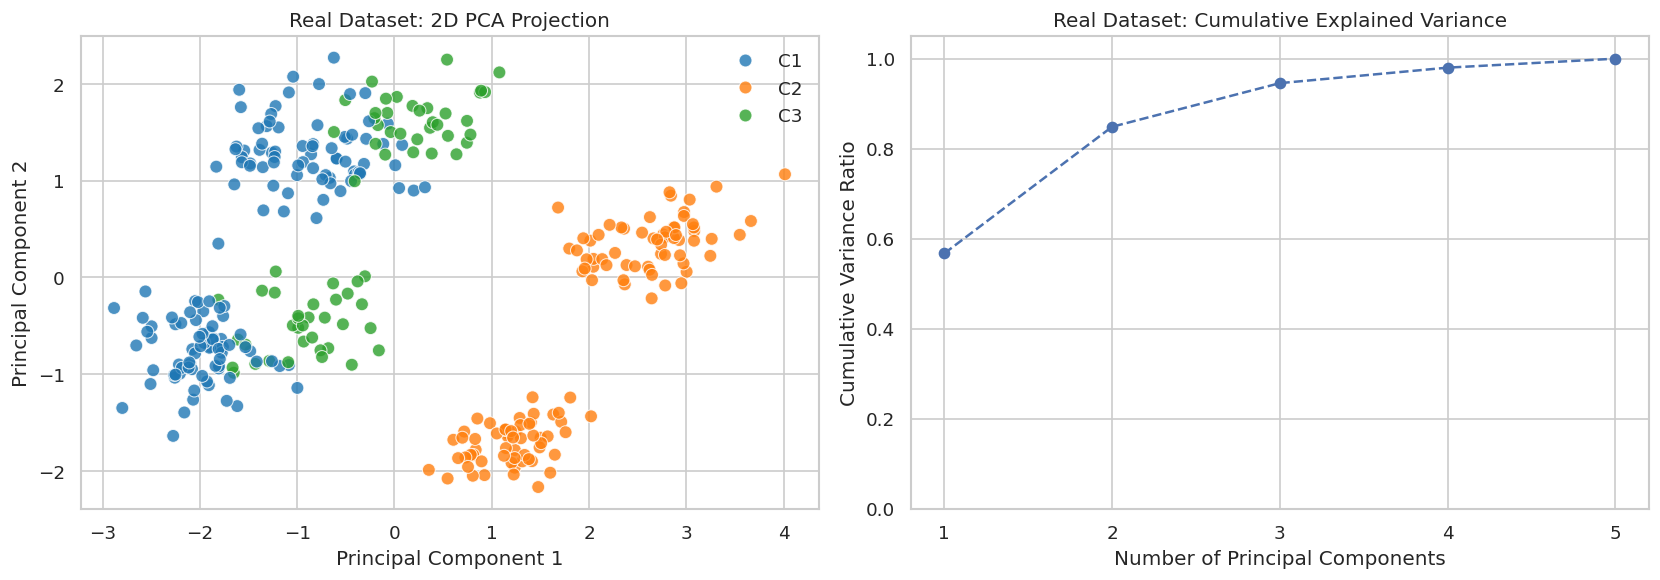

In [4]:
#PCA
from sklearn.decomposition import PCA

def execute_pca_pipeline(X: np.ndarray, labels: np.ndarray, dataset_name: str) -> np.ndarray:
    """
    Computes PCA transformation, plots the 2D projection colored by class,
    and generates the cumulative explained variance scree plot.
    """
    # Instantiate PCA keeping all components to calculate full variance spectrum
    pca = PCA()
    X_pca_full = pca.fit_transform(X)

    # 2D projection requirement
    X_pca_2d = X_pca_full[:, :2]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: 2D Latent Space Projection
    sns.scatterplot(
        x=X_pca_2d[:, 0],
        y=X_pca_2d[:, 1],
        hue=labels,
        palette='tab10',
        ax=axes[0],
        s=60,
        alpha=0.8,
        legend='full'
    )
    axes[0].set_title(f'{dataset_name}: 2D PCA Projection')
    axes[0].set_xlabel('Principal Component 1')
    axes[0].set_ylabel('Principal Component 2')

    # Plot 2: Scree Plot (Cumulative Variance)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
    axes[1].set_title(f'{dataset_name}: Cumulative Explained Variance')
    axes[1].set_xlabel('Number of Principal Components')
    axes[1].set_ylabel('Cumulative Variance Ratio')
    axes[1].set_ylim(0, 1.05)
    axes[1].set_xticks(range(1, len(cumulative_variance) + 1))

    plt.tight_layout()
    plt.show()

    return X_pca_2d

# Execute for both datasets
print("--- PCA Analysis: Synthetic Dataset ---")
X_syn_pca = execute_pca_pipeline(X_syn, meta_syn['labels'], "Synthetic Dataset")

print("\n--- PCA Analysis: Real Dataset ---")
X_real_pca = execute_pca_pipeline(X_real, meta_real['labels'], "Real Dataset")

--- t-SNE Optimization: Synthetic Dataset ---


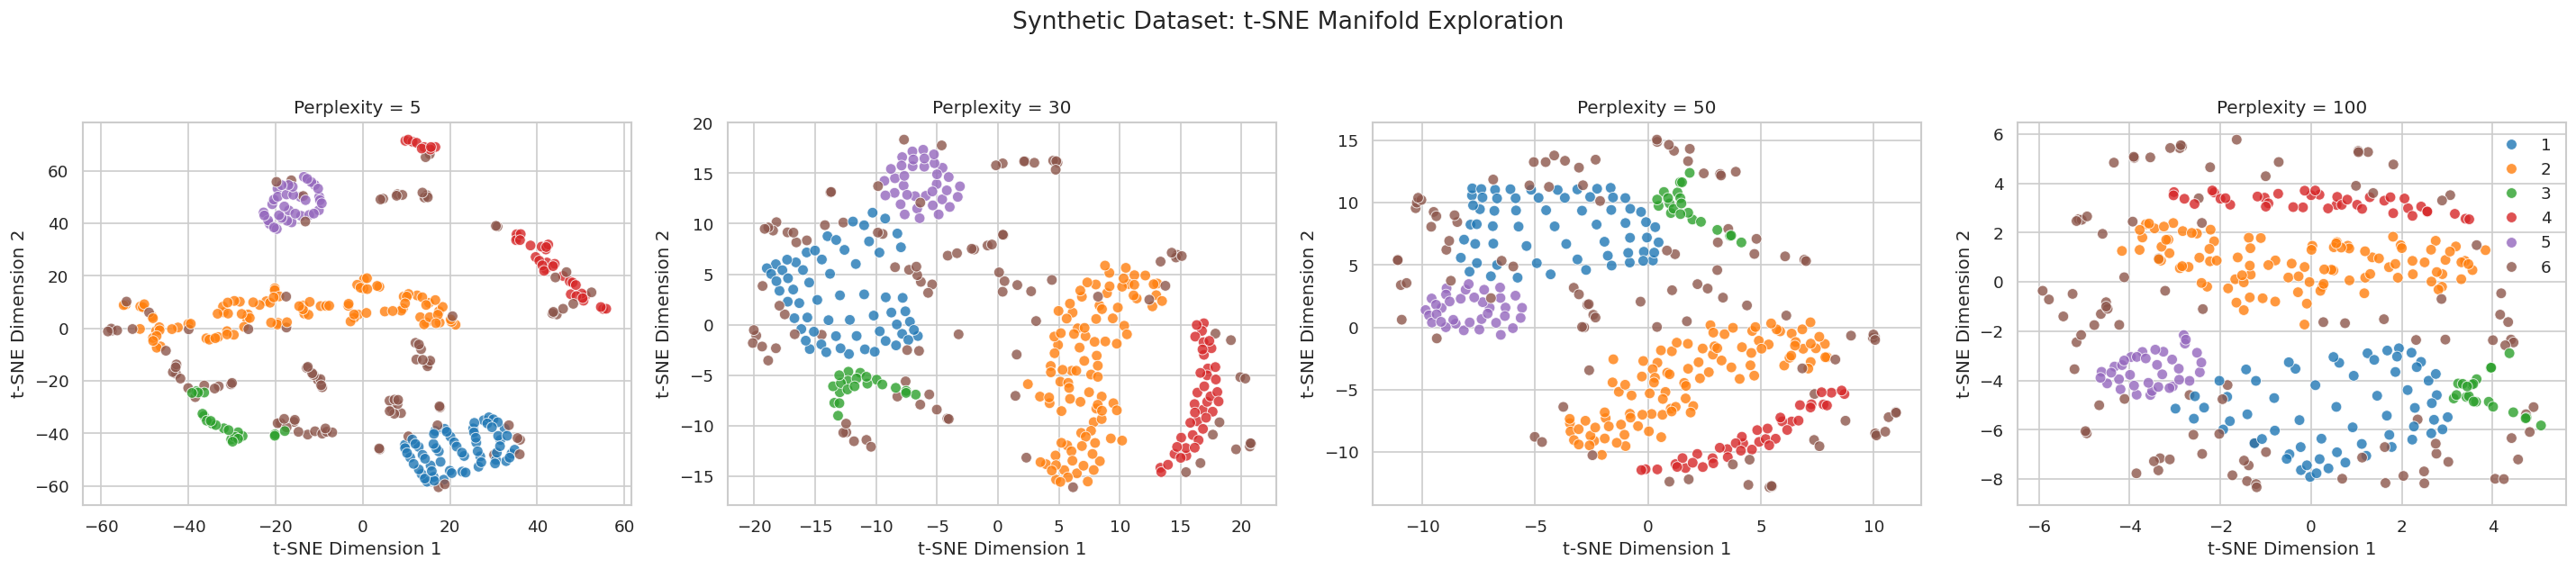


--- t-SNE Optimization: Real Dataset ---


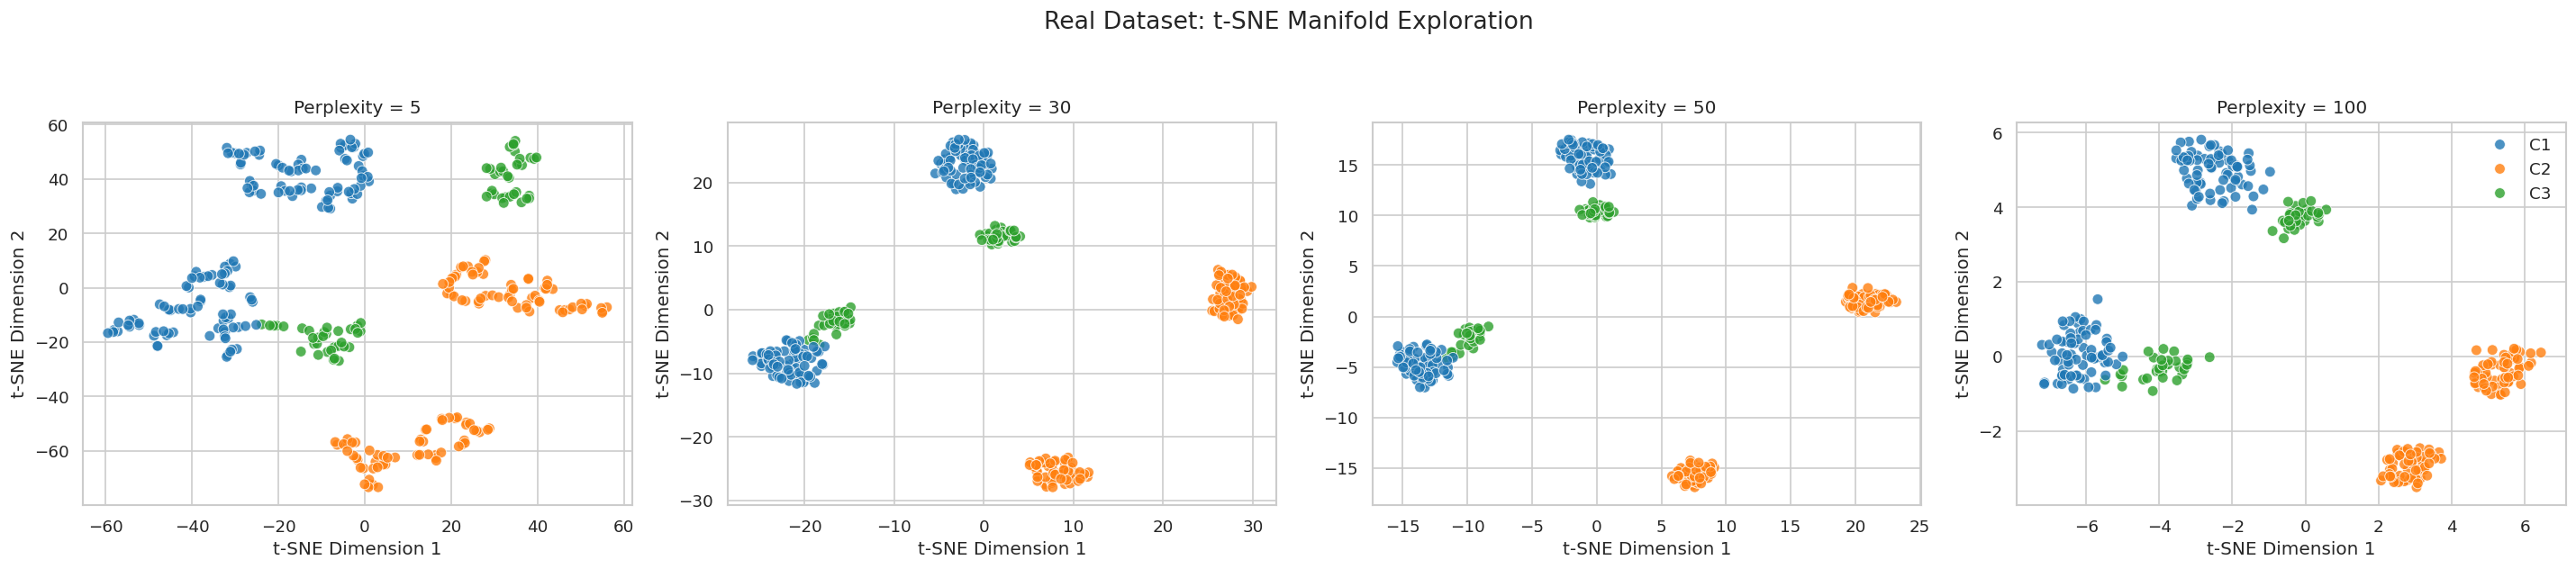

In [5]:
#t-SNE
from sklearn.manifold import TSNE

def evaluate_tsne_perplexities(X: np.ndarray, labels: np.ndarray, dataset_name: str, perplexities: list):
    """
    Computes and plots t-SNE 2D projections for a given list of perplexity values.
    Demonstrates the impact of the effective neighborhood size on local topology.
    """
    n_plots = len(perplexities)
    # Define a 1xN grid for the subplots based on the number of perplexities
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    
    if n_plots == 1:
        axes = [axes] # Ensure iterable if only one perplexity is passed
        
    for i, perplexity in enumerate(perplexities):
        # Initialize t-SNE. random_state is critical for reproducible academic benchmarks.
        # init='pca' is generally recommended over 'random' for global stability, 
        # but standard scikit-learn behavior uses 'pca' as default in newer versions anyway.
        tsne = TSNE(
            n_components=2, 
            perplexity=perplexity, 
            random_state=42, 
            init='pca',
            learning_rate='auto'
        )
        
        # Fit and transform the standardized feature matrix
        X_tsne = tsne.fit_transform(X)
        
        # Plot the 2D latent space
        sns.scatterplot(
            x=X_tsne[:, 0], 
            y=X_tsne[:, 1], 
            hue=labels, 
            palette='tab10', 
            ax=axes[i], 
            s=50, 
            alpha=0.8,
            legend='full' if i == n_plots - 1 else False # Show legend only on the last plot
        )
        
        axes[i].set_title(f'Perplexity = {perplexity}')
        axes[i].set_xlabel('t-SNE Dimension 1')
        axes[i].set_ylabel('t-SNE Dimension 2')
        
    fig.suptitle(f'{dataset_name}: t-SNE Manifold Exploration', fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

# Define hyperparameter grid: extremely local (5), standard (30, 50), and global limits (100)
perplexity_grid = [5, 30, 50, 100]

print("--- t-SNE Optimization: Synthetic Dataset ---")
evaluate_tsne_perplexities(X_syn, meta_syn['labels'], "Synthetic Dataset", perplexity_grid)

print("\n--- t-SNE Optimization: Real Dataset ---")
evaluate_tsne_perplexities(X_real, meta_real['labels'], "Real Dataset", perplexity_grid)